# Telco Customer Churn — End-to-End Analysis

**Objective:** Predict customer churn and estimate Customer Lifetime Value (CLV) for a telecom company, then translate model outputs into actionable business strategies.

**Dataset:** IBM Watson Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
**Target Variable:** `Churn` (binary: 1 = churned, 0 = retained)


##  Importing Libraries 

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Sklearn — model selection
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Sklearn — models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    recall_score, precision_score, roc_curve,
    classification_report
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# Suppress deprecation noise
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print('All libraries loaded successfully.')

All libraries loaded successfully.


##  Data Import & Initial Inspection 

In [2]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {data.shape[0]:,} rows × {data.shape[1]} columns')
data.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Fix dtypes
# TotalCharges is loaded as object due to blank strings → coerce to float
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Churn: Yes/No → 1/0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Normalise 'No internet service' / 'No phone service' → 'No'
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for c in addon_cols:
    data[c] = data[c].replace({'No internet service': 'No', 'No phone service': 'No'})

print('Missing values after type fixes:')
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values after type fixes:
TotalCharges    11
dtype: int64


## Exploratory Data Analysis
### Target Distribution

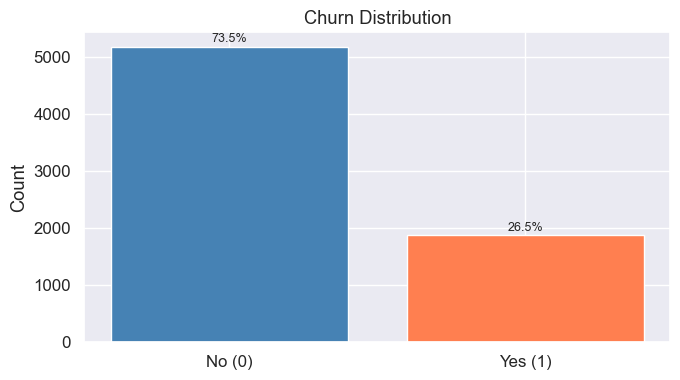

In [8]:
churn_counts = data['Churn'].value_counts()
churn_pct    = data['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No (0)', 'Yes (1)'], churn_counts,
              color=['steelblue', 'coral'], edgecolor='white')
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


###  Categorical Feature Distributions

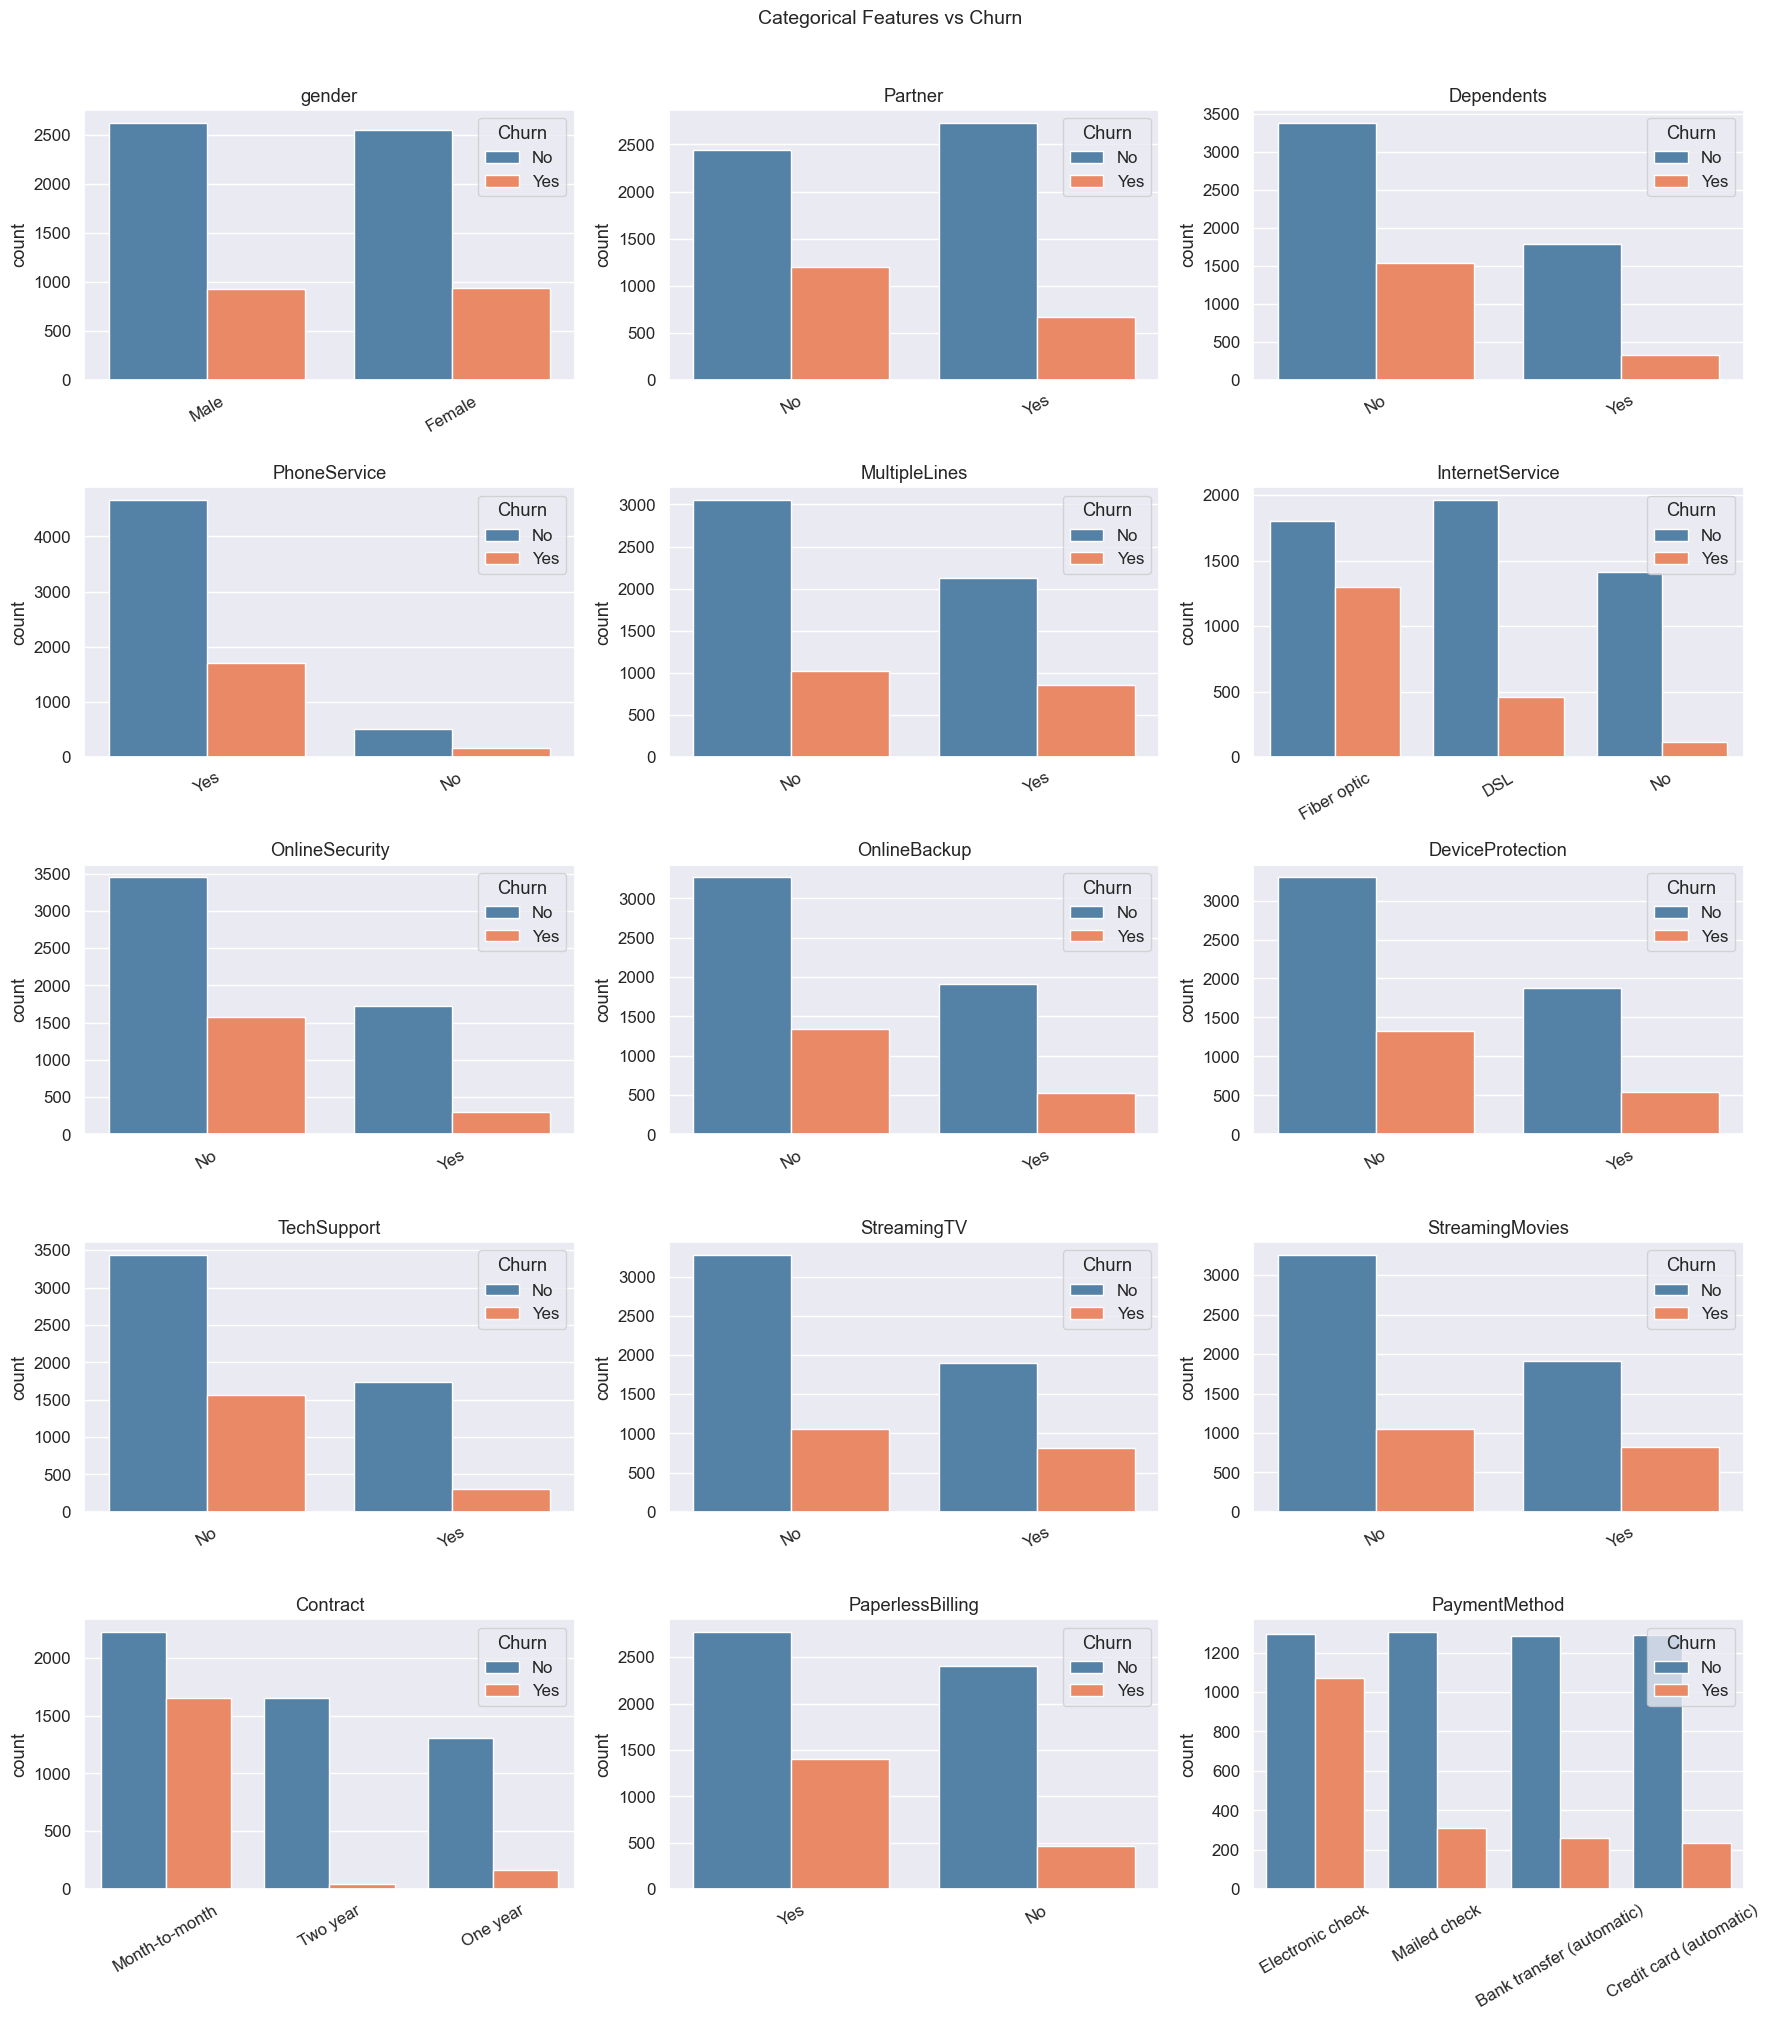

In [9]:
cat_eda_cols = data.select_dtypes(include='object').columns.drop('customerID').tolist()
n_cols = 3
n_rows = -(-len(cat_eda_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_eda_cols):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, ax=axes[i],
                  hue='Churn', palette={0: 'steelblue', 1: 'coral'})
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Churn', labels=['No', 'Yes'])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

###  Numeric Feature Distributions

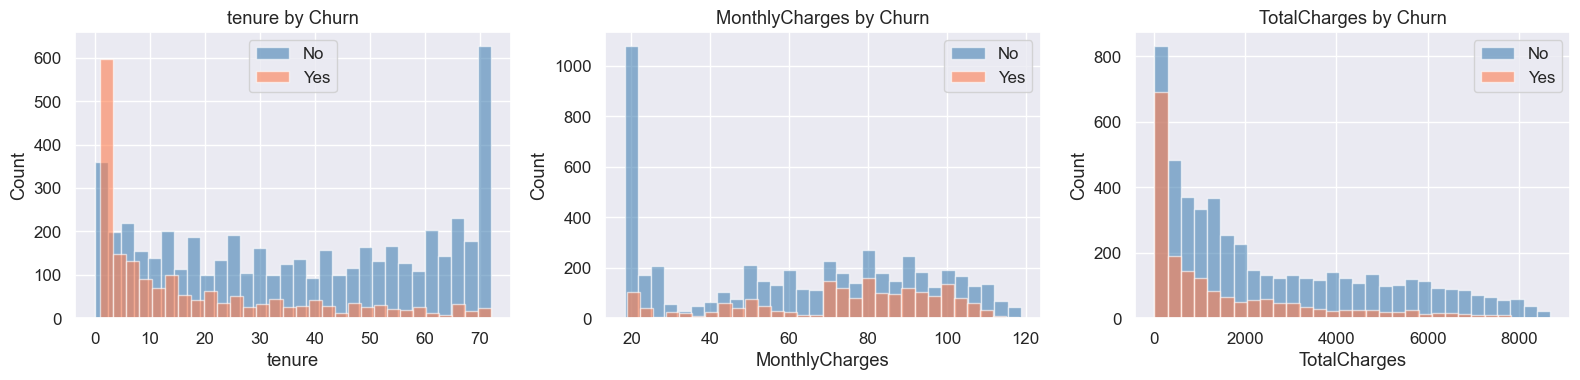

In [11]:
num_eda_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_eda_cols):
    ax.hist(data.loc[data['Churn']==0, col].dropna(), bins=30,
            alpha=0.6, label='No', color='steelblue')
    ax.hist(data.loc[data['Churn']==1, col].dropna(), bins=30,
            alpha=0.6, label='Yes',  color='coral')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

###  Churn Rates by Key Segments

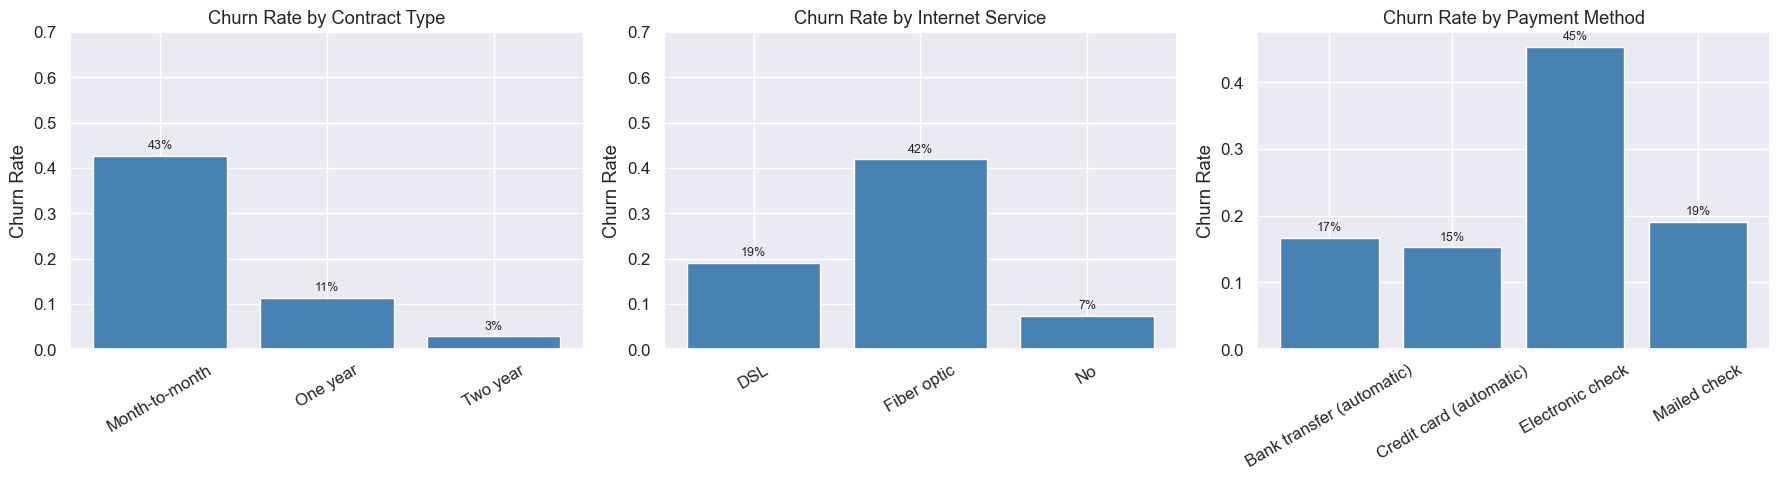

In [12]:
def plot_churn_rate(col, order=None, title=None, ax=None, ylim=(0, 0.7)):
    """Bar chart of churn rate for a categorical column."""
    if col not in data.columns:
        return
    rates = data.groupby(col)['Churn'].mean()
    if order:
        rates = rates.reindex(order)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(rates.index, rates.values, color='steelblue', edgecolor='white')
    ax.set_title(title or f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, rates.values):
        ax.annotate(f'{v:.0%}', (bar.get_x() + bar.get_width()/2, v),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_churn_rate('Contract',
                order=['Month-to-month', 'One year', 'Two year'],
                title='Churn Rate by Contract Type', ax=axes[0])
plot_churn_rate('InternetService',
                order=['DSL', 'Fiber optic', 'No'],
                title='Churn Rate by Internet Service', ax=axes[1])
plot_churn_rate('PaymentMethod',
                title='Churn Rate by Payment Method', ax=axes[2], ylim=None)
plt.tight_layout()
plt.show()

## Data Preparation & Feature Engineering 

We create a copy `dff` to preserve the original `data` for EDA, then add engineered features.

In [13]:
dff = data.copy()

# ── Contract × Tenure interactions ──────────────────────────────────────────
dff['Tenure_Contract_MonthToMonth'] = (dff['Contract'] == 'Month-to-month').astype(int) * dff['tenure']
dff['Tenure_Contract_OneYear']      = (dff['Contract'] == 'One year').astype(int)        * dff['tenure']
dff['Tenure_Contract_TwoYear']      = (dff['Contract'] == 'Two year').astype(int)        * dff['tenure']

# ── Average monthly spend (avoids TotalCharges=0 for new customers) ─────────
dff['avg_monthly'] = dff.apply(
    lambda r: r['MonthlyCharges'] if r['tenure'] == 0 else r['TotalCharges'] / r['tenure'],
    axis=1
)

# ── Service adoption count ───────────────────────────────────────────────────
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies',
              'MultipleLines', 'PhoneService']
dff['addon_services_count'] = dff[addon_cols].apply(
    lambda col: (col == 'Yes').astype(int)
).sum(axis=1)

# ── Tenure group (categorical bucketing) ─────────────────────────────────────
dff['tenure_group'] = pd.cut(dff['tenure'],
                              bins=[0, 12, 24, 48, 72],
                              labels=['0-12m', '12-24m', '24-48m', '48-72m'])

# ── Binary flags ─────────────────────────────────────────────────────────────
dff['is_month_to_month']    = (dff['Contract'] == 'Month-to-month').astype(int)
dff['is_fiber']             = (dff['InternetService'] == 'Fiber optic').astype(int)
dff['has_multiple_services']= (dff['addon_services_count'] >= 3).astype(int)

# ── Spend efficiency features ─────────────────────────────────────────────────
dff['charge_per_service'] = dff['MonthlyCharges'] / (dff['addon_services_count'] + 1)
dff['tenure_per_service'] = dff['tenure']         / (dff['addon_services_count'] + 1)
dff['charges_diff']       = dff['TotalCharges']   - dff['tenure'] * dff['MonthlyCharges']

# ── Drop ID column ────────────────────────────────────────────────────────────
dff.drop(columns=['customerID'], inplace=True, errors='ignore')

print(f'Feature-engineered shape: {dff.shape}')
dff.head(3)

Feature-engineered shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Tenure_Contract_TwoYear,avg_monthly,addon_services_count,tenure_group,is_month_to_month,is_fiber,has_multiple_services,charge_per_service,tenure_per_service,charges_diff
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,0,29.850000,1,0-12m,1,0,0,14.9250,0.5,0.00
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,55.573529,3,24-48m,0,0,1,14.2375,8.5,-46.80
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,0,54.075000,3,0-12m,1,0,1,13.4625,0.5,0.45


##  Preprocessing 

In [14]:
# Drop rows with missing values (only 11 rows from TotalCharges)
dff.dropna(inplace=True)

X = dff.drop(columns=['Churn'])
y = dff['Churn'].astype(int)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Samples: {X.shape[0]:,} | Features: {X.shape[1]}')
print(f'Positive class (churned): {y.mean():.1%}')
print(f'\nCategorical ({len(cat_cols)}):',  ', '.join(cat_cols))
print(f'Numeric     ({len(num_cols)}):',  ', '.join(num_cols))

Samples: 7,032 | Features: 31
Positive class (churned): 26.6%

Categorical (16): gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, tenure_group
Numeric     (15): SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Tenure_Contract_MonthToMonth, Tenure_Contract_OneYear, Tenure_Contract_TwoYear, avg_monthly, addon_services_count, is_month_to_month, is_fiber, has_multiple_services, charge_per_service, tenure_per_service, charges_diff


In [15]:

# preproc_scaled : for distance/gradient-based models (LR, KNN)
# preproc_tree   : for tree-based models (DT, RF, XGBoost) — no scaling needed

preproc_scaled = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), num_cols)
])

preproc_tree = ColumnTransformer([
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median'))
    ]), num_cols)
])

print('Preprocessors defined.')

Preprocessors defined.


##  Model Pipelines 

In [16]:
models = {
    'Decision Tree': {
        'pipe': ImbPipeline([
            ('preprocess', preproc_tree),
            ('smote',      SMOTE(random_state=42)),
            ('model',      DecisionTreeClassifier(random_state=42))
        ]),
        'grid': {
            'smote':                    [None, SMOTE(random_state=42)],
            'model__max_depth':         [3, 5, 8, None],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf':  [1, 5, 10],
            'model__class_weight':      [None, 'balanced']
        }
    },
    'Logistic Regression': {
        'pipe': ImbPipeline([
            ('preprocess', preproc_scaled),
            ('smote',      SMOTE(random_state=42)),
            ('model',      LogisticRegression(max_iter=2000, solver='saga'))
        ]),
        'grid': {
            'model__C':            [0.1, 1, 3],
            'model__l1_ratio':     [0.0, 0.5, 1.0],  # 0=L2, 1=L1, 0.5=ElasticNet
            'model__class_weight': [None, 'balanced']
        }
    },
    'KNN': {
        'pipe': ImbPipeline([
            ('preprocess', preproc_scaled),
            ('smote',      SMOTE(random_state=42)),
            ('model',      KNeighborsClassifier())
        ]),
        'grid': {
            'model__n_neighbors': [3, 5, 7, 11],
            'model__weights':     ['uniform', 'distance'],
            'model__p':           [1, 2]
        }
    },
    'Random Forest': {
        'pipe': ImbPipeline([
            ('preprocess', preproc_tree),
            ('smote',      SMOTE(random_state=42)),
            ('model',      RandomForestClassifier(random_state=42))
        ]),
        'grid': {
            'smote':                    [None, SMOTE(random_state=42)],
            'model__n_estimators':      [100, 200],
            'model__max_depth':         [5, 10, None],
            'model__min_samples_split': [2, 10],
            'model__class_weight':      [None, 'balanced']
        }
    },
    'XGBoost': {
        'pipe': ImbPipeline([
            ('preprocess', preproc_tree),
            ('smote',      SMOTE(random_state=42)),
            ('model',      XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        'grid': {
            'smote':                     [None, SMOTE(random_state=42)],
            'model__n_estimators':       [100, 200],
            'model__max_depth':          [3, 5, 7],
            'model__learning_rate':      [0.01, 0.1, 0.3],
            'model__scale_pos_weight':   [1, 3]
        }
    }
}

print(f'{len(models)} model pipelines defined:', list(models.keys()))

5 model pipelines defined: ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']


##  Nested Cross-Validation & Model Selection 

We use **nested CV** to get honest, leakage-free performance estimates:
- **Outer loop** (5 folds): evaluate generalisation on held-out data
- **Inner loop** (5 folds): tune hyperparameters via GridSearchCV

Out-of-fold (OOF) probabilities are collected to build the final ROC curves.


── Decision Tree ──
  Fold 1 | AUC=0.831  F1=0.612
  Fold 2 | AUC=0.836  F1=0.565
  Fold 3 | AUC=0.826  F1=0.524
  Fold 4 | AUC=0.826  F1=0.589
  Fold 5 | AUC=0.815  F1=0.545

── Logistic Regression ──
  Fold 1 | AUC=0.847  F1=0.643
  Fold 2 | AUC=0.850  F1=0.629
  Fold 3 | AUC=0.847  F1=0.636
  Fold 4 | AUC=0.843  F1=0.624
  Fold 5 | AUC=0.841  F1=0.614

── KNN ──
  Fold 1 | AUC=0.800  F1=0.590
  Fold 2 | AUC=0.814  F1=0.589
  Fold 3 | AUC=0.805  F1=0.581
  Fold 4 | AUC=0.822  F1=0.605
  Fold 5 | AUC=0.804  F1=0.598

── Random Forest ──
  Fold 1 | AUC=0.844  F1=0.612
  Fold 2 | AUC=0.854  F1=0.640
  Fold 3 | AUC=0.839  F1=0.625
  Fold 4 | AUC=0.842  F1=0.635
  Fold 5 | AUC=0.835  F1=0.555

── XGBoost ──
  Fold 1 | AUC=0.845  F1=0.615
  Fold 2 | AUC=0.853  F1=0.642
  Fold 3 | AUC=0.849  F1=0.569
  Fold 4 | AUC=0.843  F1=0.582
  Fold 5 | AUC=0.840  F1=0.595


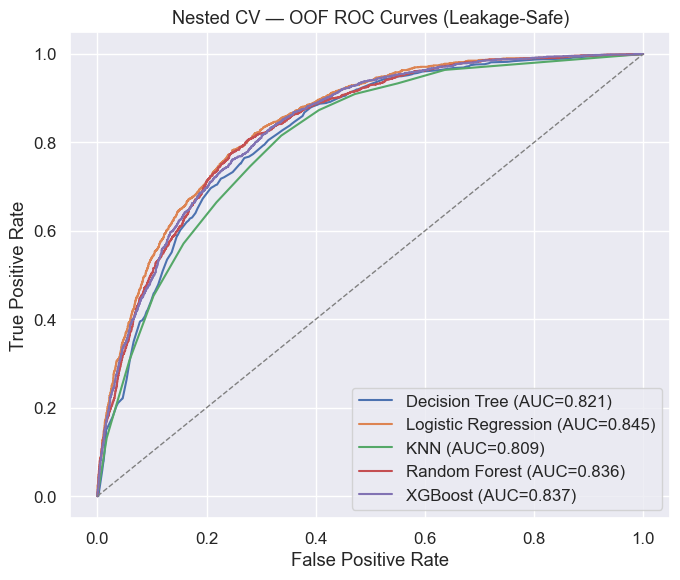

In [17]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

summary_rows        = []
inner_vs_nested_rows= []
best_params_votes   = {}
oof_probs_all       = {}   # store per-model OOF probs for threshold tuning

fig, ax = plt.subplots(figsize=(7, 6))

for name, cfg in models.items():
    print(f'\n── {name} ──')
    oof_probs    = np.zeros(len(y))
    oof_true     = y.values.copy()
    fold_metrics = []
    fold_params  = []
    inner_scores = []

    for k, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        grid = GridSearchCV(cfg['pipe'], cfg['grid'],
                            cv=inner_cv, scoring='roc_auc',
                            n_jobs=-1, refit=True)
        grid.fit(X_tr, y_tr)
        inner_scores.append(grid.best_score_)
        fold_params.append(grid.best_params_)

        probs = grid.best_estimator_.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)
        oof_probs[te_idx] = probs

        fold_metrics.append({
            'AUC':       roc_auc_score(y_te, probs),
            'Accuracy':  accuracy_score(y_te, preds),
            'F1':        f1_score(y_te, preds),
            'Recall':    recall_score(y_te, preds),
            'Precision': precision_score(y_te, preds, zero_division=0)
        })
        print(f'  Fold {k} | AUC={fold_metrics[-1]["AUC"]:.3f}  F1={fold_metrics[-1]["F1"]:.3f}')

    # ROC curve
    fpr, tpr, _ = roc_curve(oof_true, oof_probs)
    oof_auc = roc_auc_score(oof_true, oof_probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={oof_auc:.3f})')

    oof_probs_all[name] = oof_probs.copy()

    AUCs = [m['AUC'] for m in fold_metrics]
    summary_rows.append({
        'Model':     name,
        'Mean AUC':  np.mean(AUCs),
        'Std AUC':   np.std(AUCs),
        'OOF AUC':   oof_auc,
        'Accuracy':  accuracy_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'F1':        f1_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'Recall':    recall_score(oof_true, (oof_probs >= 0.5).astype(int)),
        'Precision': precision_score(oof_true, (oof_probs >= 0.5).astype(int), zero_division=0)
    })

    inner_vs_nested_rows.append({
        'Model':              name,
        'Non-nested AUC':     np.mean(inner_scores),
        'Nested OOF AUC':     oof_auc,
        'Optimism Bias':      np.mean(inner_scores) - oof_auc
    })

    vote = Counter(tuple(sorted(p.items())) for p in fold_params)
    best_params_votes[name] = dict(vote.most_common(1)[0][0])

ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Nested CV — OOF ROC Curves (Leakage-Safe)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [18]:
summary_df = pd.DataFrame(summary_rows).sort_values('OOF AUC', ascending=False)
print('=== Model Performance Summary ===')
print(summary_df.set_index('Model').round(3).to_string())

print('\n=== Non-Nested vs Nested AUC (Optimism Bias) ===')
nn_df = pd.DataFrame(inner_vs_nested_rows)
print(nn_df.set_index('Model').round(3).to_string())

=== Model Performance Summary ===
                     Mean AUC  Std AUC  OOF AUC  Accuracy     F1  Recall  Precision
Model                                                                              
Logistic Regression     0.846    0.003    0.845     0.753  0.629   0.790      0.523
XGBoost                 0.846    0.005    0.837     0.794  0.604   0.591      0.618
Random Forest           0.843    0.007    0.836     0.781  0.617   0.663      0.576
Decision Tree           0.827    0.007    0.821     0.782  0.569   0.541      0.600
KNN                     0.809    0.008    0.809     0.727  0.592   0.746      0.491

=== Non-Nested vs Nested AUC (Optimism Bias) ===
                     Non-nested AUC  Nested OOF AUC  Optimism Bias
Model                                                             
Decision Tree                 0.826           0.821          0.006
Logistic Regression           0.845           0.845         -0.001
KNN                           0.812           0.809         

## Final Model Fitting <a id='8'></a>

In [19]:
final_models = {}
for name, cfg in models.items():
    params = {k: v for k, v in best_params_votes[name].items()}
    final_pipe = cfg['pipe'].set_params(**params)
    final_pipe.fit(X, y)
    final_models[name] = final_pipe
    print(f'{name:25s} — fitted  |  best params: {params}')

Decision Tree             — fitted  |  best params: {'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2, 'smote': None}
Logistic Regression       — fitted  |  best params: {'model__C': 0.1, 'model__class_weight': None, 'model__l1_ratio': 1.0}
KNN                       — fitted  |  best params: {'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'uniform'}
Random Forest             — fitted  |  best params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 200, 'smote': SMOTE(random_state=42)}
XGBoost                   — fitted  |  best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1, 'smote': None}


## Feature Importance & Interpretability <a id='9'></a>

── Decision Tree — Top 15 Features ──


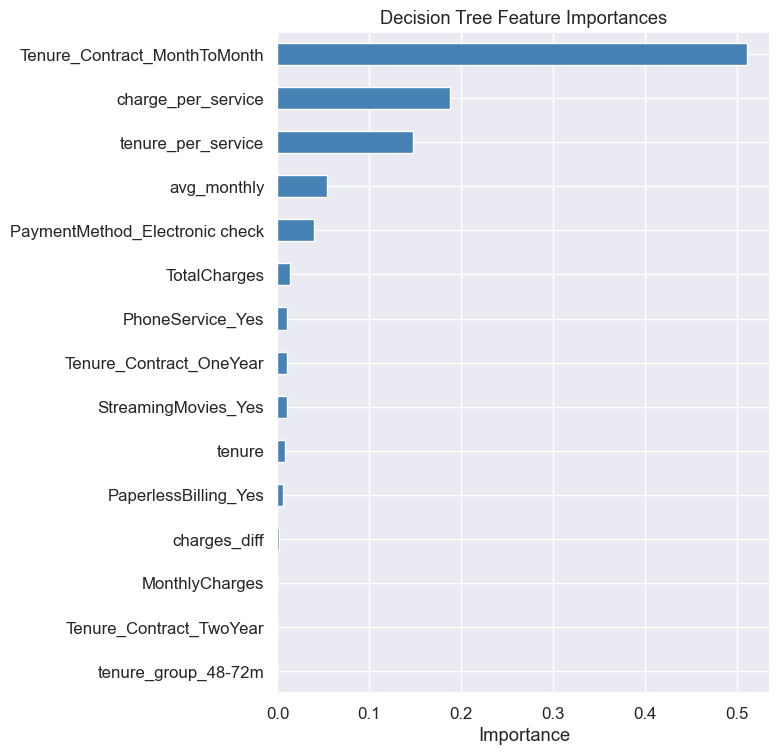

Tenure_Contract_MonthToMonth      0.510545
charge_per_service                0.187609
tenure_per_service                0.147888
avg_monthly                       0.053882
PaymentMethod_Electronic check    0.039368
TotalCharges                      0.013460
PhoneService_Yes                  0.010741
Tenure_Contract_OneYear           0.010075
StreamingMovies_Yes               0.009911
tenure                            0.008300
PaperlessBilling_Yes              0.006459
charges_diff                      0.001762
MonthlyCharges                    0.000000
Tenure_Contract_TwoYear           0.000000
tenure_group_48-72m               0.000000
dtype: float64


In [20]:
def get_feature_names(preproc, X_df):
    """Extract OHE + numeric feature names from a fitted ColumnTransformer."""
    ohe      = preproc.named_transformers_['cat'].named_steps['encode']
    cat_names= ohe.get_feature_names_out(preproc.transformers_[0][2]).tolist()
    num_names= list(preproc.transformers_[1][2])
    return cat_names + num_names


def plot_top_features(importances, names, title, top_n=15, color='steelblue'):
    """Horizontal bar chart of top N features."""
    s = pd.Series(importances, index=names).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, 0.45 * top_n + 1))
    s[::-1].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return s


# ── Decision Tree ─────────────────────────────────────────────────────────────
tree_pipe   = final_models['Decision Tree']
tree_names  = get_feature_names(tree_pipe.named_steps['preprocess'], X)
tree_imp    = tree_pipe.named_steps['model'].feature_importances_
print('── Decision Tree — Top 15 Features ──')
dt_top = plot_top_features(tree_imp, tree_names,
                            'Decision Tree Feature Importances', color='steelblue')
print(dt_top)

── Logistic Regression — Top 15 Odds Ratios ──


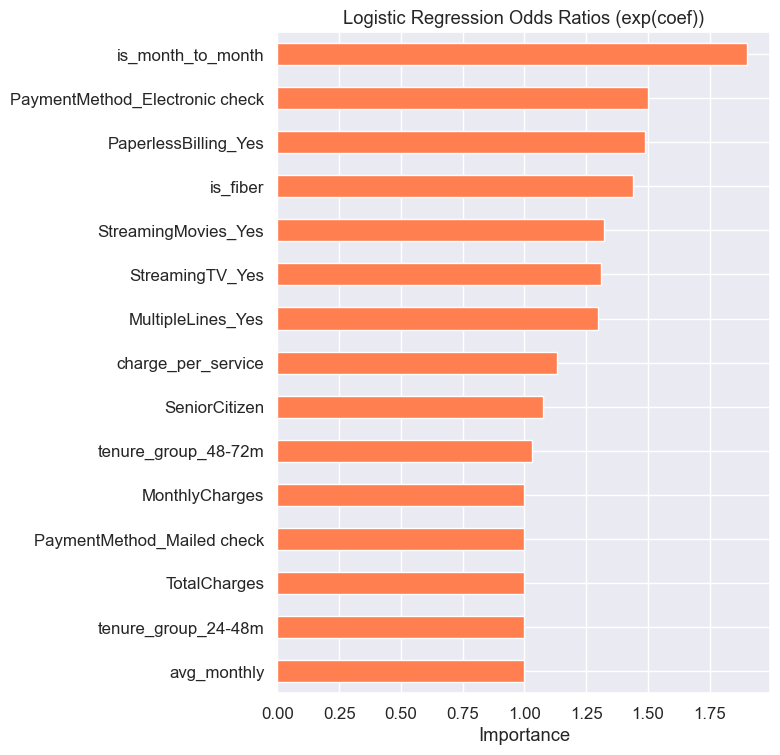

is_month_to_month                 1.901413
PaymentMethod_Electronic check    1.500731
PaperlessBilling_Yes              1.488644
is_fiber                          1.439804
StreamingMovies_Yes               1.324507
StreamingTV_Yes                   1.309316
MultipleLines_Yes                 1.296370
charge_per_service                1.131892
SeniorCitizen                     1.074138
tenure_group_48-72m               1.031557
MonthlyCharges                    1.000000
PaymentMethod_Mailed check        1.000000
TotalCharges                      1.000000
tenure_group_24-48m               1.000000
avg_monthly                       1.000000
dtype: float64


In [21]:
# ── Logistic Regression — Odds Ratios ────────────────────────────────────────
log_pipe   = final_models['Logistic Regression']
log_names  = get_feature_names(log_pipe.named_steps['preprocess'], X)
coefs      = log_pipe.named_steps['model'].coef_.ravel()
odds_ratios= np.exp(coefs)

print('── Logistic Regression — Top 15 Odds Ratios ──')
lr_top = plot_top_features(odds_ratios, log_names,
                            'Logistic Regression Odds Ratios (exp(coef))',
                            color='coral')
print(lr_top)

── Random Forest — Top 15 Features ──


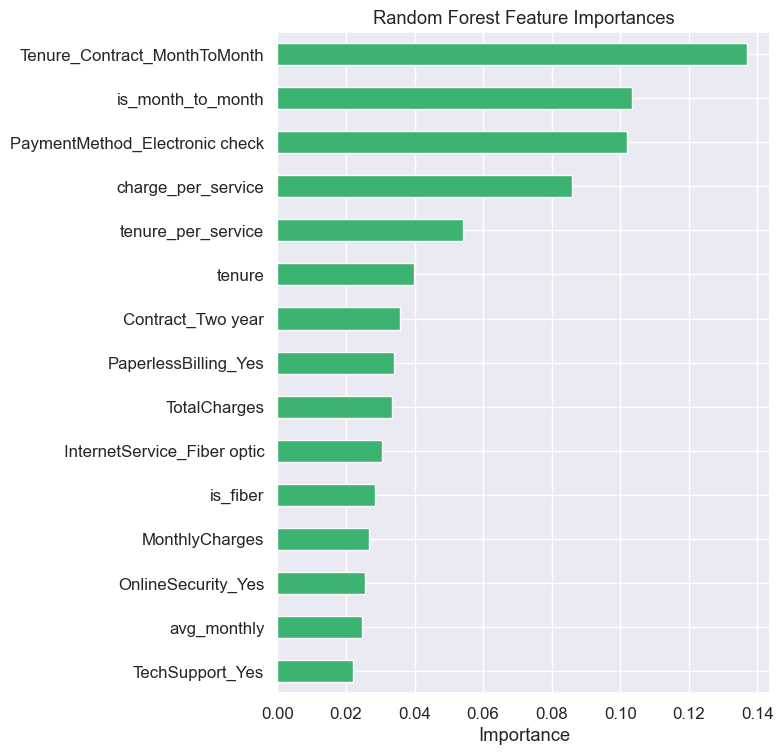

Tenure_Contract_MonthToMonth      0.136995
is_month_to_month                 0.103452
PaymentMethod_Electronic check    0.101901
charge_per_service                0.085932
tenure_per_service                0.054249
tenure                            0.039703
Contract_Two year                 0.035805
PaperlessBilling_Yes              0.033985
TotalCharges                      0.033469
InternetService_Fiber optic       0.030452
is_fiber                          0.028387
MonthlyCharges                    0.026683
OnlineSecurity_Yes                0.025573
avg_monthly                       0.024683
TechSupport_Yes                   0.021933
dtype: float64


In [22]:
# ── Random Forest — Built-in Importances ─────────────────────────────────────
rf_pipe   = final_models['Random Forest']
rf_names  = get_feature_names(rf_pipe.named_steps['preprocess'], X)
rf_imp    = rf_pipe.named_steps['model'].feature_importances_

print('── Random Forest — Top 15 Features ──')
rf_top = plot_top_features(rf_imp, rf_names,
                            'Random Forest Feature Importances', color='mediumseagreen')
print(rf_top)

── XGBoost — Top 15 Features ──


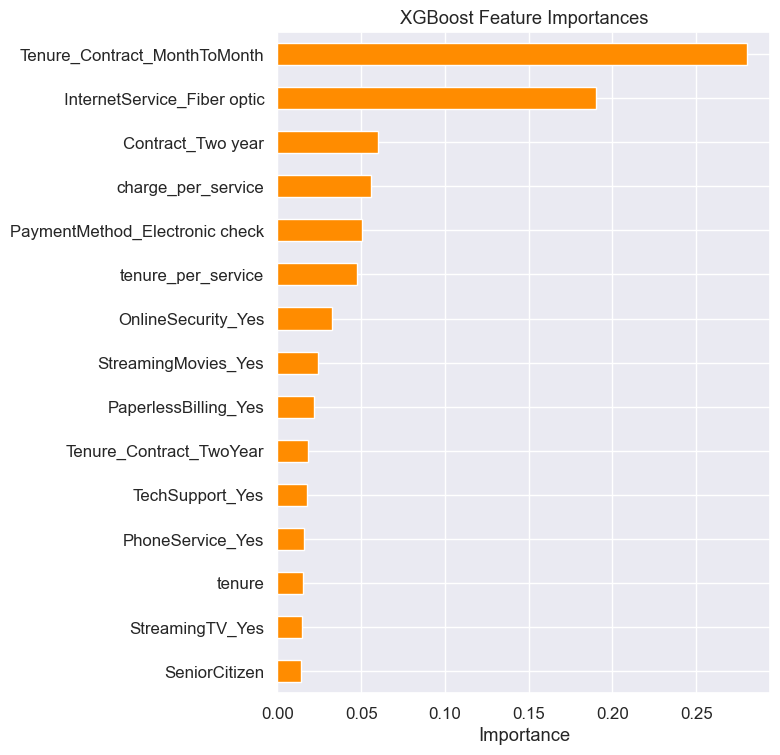

Tenure_Contract_MonthToMonth      0.280313
InternetService_Fiber optic       0.190496
Contract_Two year                 0.059952
charge_per_service                0.055616
PaymentMethod_Electronic check    0.050748
tenure_per_service                0.047207
OnlineSecurity_Yes                0.032545
StreamingMovies_Yes               0.024085
PaperlessBilling_Yes              0.021588
Tenure_Contract_TwoYear           0.018342
TechSupport_Yes                   0.017604
PhoneService_Yes                  0.015725
tenure                            0.015391
StreamingTV_Yes                   0.014856
SeniorCitizen                     0.013970
dtype: float32


In [23]:
# ── XGBoost — Built-in Importances ───────────────────────────────────────────
xgb_pipe  = final_models['XGBoost']
xgb_names = get_feature_names(xgb_pipe.named_steps['preprocess'], X)
xgb_imp   = xgb_pipe.named_steps['model'].feature_importances_

print('── XGBoost — Top 15 Features ──')
xgb_top = plot_top_features(xgb_imp, xgb_names,
                             'XGBoost Feature Importances', color='darkorange')
print(xgb_top)

── KNN — Permutation Importance (Top 15) ──


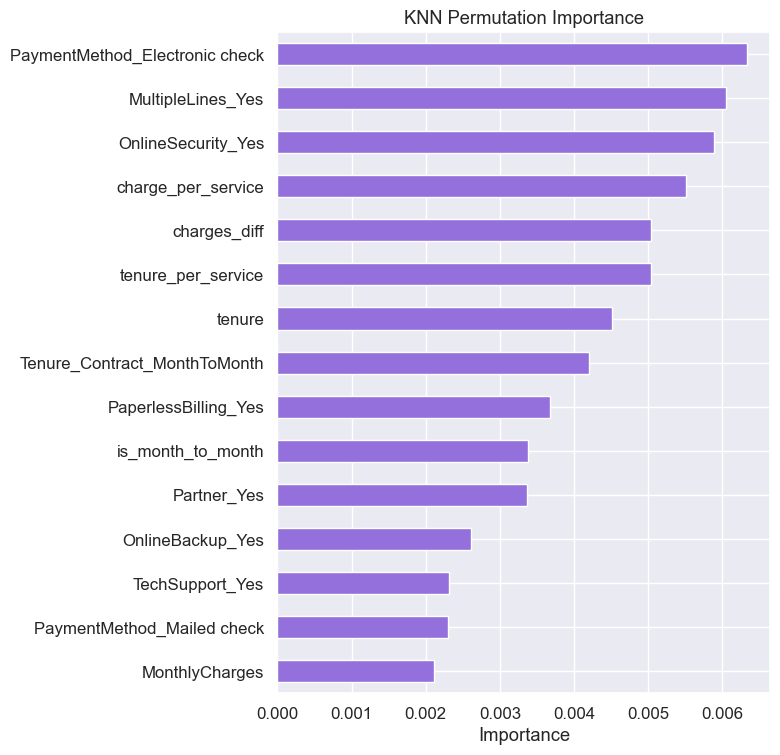

PaymentMethod_Electronic check    0.006332
MultipleLines_Yes                 0.006054
OnlineSecurity_Yes                0.005890
charge_per_service                0.005513
charges_diff                      0.005044
tenure_per_service                0.005039
tenure                            0.004508
Tenure_Contract_MonthToMonth      0.004199
PaperlessBilling_Yes              0.003681
is_month_to_month                 0.003382
Partner_Yes                       0.003361
OnlineBackup_Yes                  0.002605
TechSupport_Yes                   0.002315
PaymentMethod_Mailed check        0.002303
MonthlyCharges                    0.002112
dtype: float64


In [24]:
# ── KNN — Permutation Importance ─────────────────────────────────────────────
split       = next(iter(StratifiedKFold(n_splits=5, shuffle=True, random_state=1).split(X, y)))
X_tr_knn, X_te_knn = X.iloc[split[0]], X.iloc[split[1]]
y_tr_knn, y_te_knn = y.iloc[split[0]], y.iloc[split[1]]

knn_tmp = models['KNN']['pipe'].set_params(**best_params_votes['KNN'])
knn_tmp.fit(X_tr_knn, y_tr_knn)

X_te_enc      = knn_tmp.named_steps['preprocess'].transform(X_te_knn)
feat_names_knn= get_feature_names(knn_tmp.named_steps['preprocess'], X)
pi = permutation_importance(knn_tmp.named_steps['model'], X_te_enc, y_te_knn,
                            n_repeats=10, random_state=0, scoring='roc_auc')

print('── KNN — Permutation Importance (Top 15) ──')
knn_top = plot_top_features(pi.importances_mean, feat_names_knn,
                             'KNN Permutation Importance', color='mediumpurple')
print(knn_top)

##  Threshold Tuning 

For churn, **recall** (catching churners) matters more than precision. We plot Precision, Recall, and F1 across decision thresholds to find the optimal operating point.

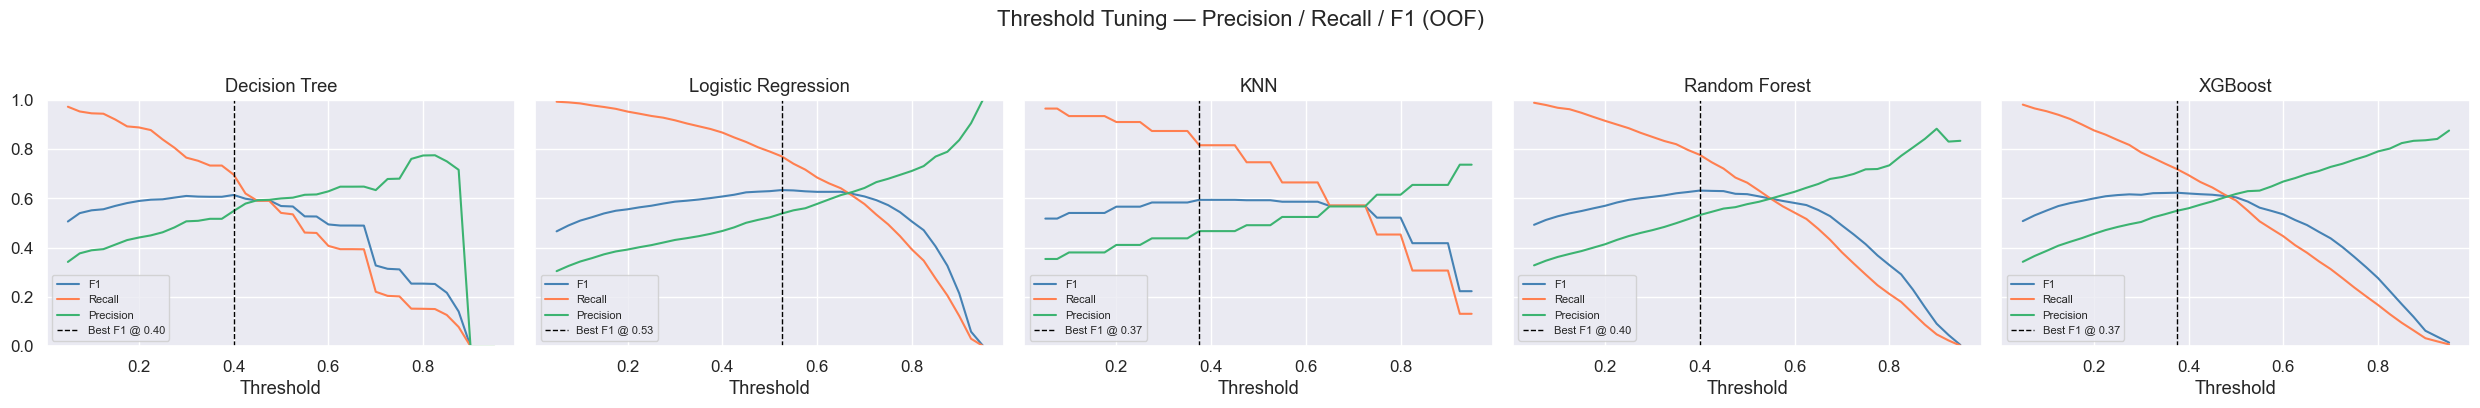

                     Best Threshold  Best F1
Model                                       
Decision Tree                 0.400    0.614
Logistic Regression           0.525    0.634
KNN                           0.375    0.594
Random Forest                 0.400    0.632
XGBoost                       0.375    0.623


In [25]:
def plot_threshold_curve(oof_true, oof_probs, name, ax):
    """Plot Precision/Recall/F1 vs decision threshold."""
    ths  = np.linspace(0.05, 0.95, 37)
    recs, pres, f1s = [], [], []
    for t in ths:
        preds = (oof_probs >= t).astype(int)
        recs.append(recall_score(oof_true,    preds, zero_division=0))
        pres.append(precision_score(oof_true, preds, zero_division=0))
        f1s.append(f1_score(oof_true,         preds, zero_division=0))
    best_t = ths[np.argmax(f1s)]
    ax.plot(ths, f1s,  label='F1',        color='steelblue')
    ax.plot(ths, recs, label='Recall',    color='coral')
    ax.plot(ths, pres, label='Precision', color='mediumseagreen')
    ax.axvline(best_t, color='black', linestyle='--', linewidth=1,
               label=f'Best F1 @ {best_t:.2f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Threshold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    return best_t, max(f1s)


n = len(models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)

threshold_summary = []
for ax, (name, _) in zip(axes, models.items()):
    best_t, best_f1 = plot_threshold_curve(y.values, oof_probs_all[name], name, ax)
    threshold_summary.append({'Model': name, 'Best Threshold': best_t, 'Best F1': best_f1})

plt.suptitle('Threshold Tuning — Precision / Recall / F1 (OOF)', y=1.02)
plt.tight_layout()
plt.show()

print(pd.DataFrame(threshold_summary).set_index('Model').round(3))

## Customer Lifetime Value Estimation

**Methodology:**
- CLV is estimated using the best-performing model's predicted churn probability.
- Expected remaining lifespan = `1 / churn_probability` (geometric distribution of churn).
- CLV = `Monthly Charges × Expected Lifespan × Annual Discount Factor`
- **Discount rate:** 10% annually (standard telecoms assumption)

In [ ]:
DISCOUNT_RATE  = 0.10
ANNUAL_FACTOR  = 1 / (1 + DISCOUNT_RATE)

# Use best model by OOF AUC
best_model_name = summary_df.iloc[0]['Model']
print(f'Using best model: {best_model_name}')

best_model  = final_models[best_model_name]
churn_proba = best_model.predict_proba(X)[:, 1]

clv_df = X[['MonthlyCharges', 'tenure']].copy()
clv_df['churn_probability']      = churn_proba
clv_df['retention_probability']  = 1 - churn_proba
clv_df['expected_lifespan_months'] = 1 / clv_df['churn_probability'].clip(lower=0.01)
clv_df['CLV'] = (clv_df['MonthlyCharges'] * clv_df['expected_lifespan_months'] * ANNUAL_FACTOR)

clv_df['CLV_Segment'] = pd.cut(
    clv_df['CLV'],
    bins=[0, 200, 600, 1500, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium']
)
clv_df['Churn_Label'] = y.values

print(clv_df[['MonthlyCharges', 'churn_probability', 'expected_lifespan_months', 'CLV']].describe().round(2))

Using best model: Logistic Regression
       MonthlyCharges  churn_probability  expected_lifespan_months      CLV
count         7032.00            7032.00                   7032.00  7032.00
mean            64.80               0.41                     10.91   409.32
std             30.09               0.30                     20.08   545.82
min             18.25               0.00                      1.05    25.00
25%             35.59               0.11                      1.46    91.03
50%             70.35               0.38                      2.60   158.12
75%             89.86               0.68                      9.45   472.48
max            118.75               0.95                    100.00  4513.40


In [27]:
clv_df.head()

,MonthlyCharges,tenure,churn_probability,retention_probability,expected_lifespan_months,CLV,CLV_Segment,Churn_Label
0,29.85,1,0.818250,0.181750,1.222121,33.163919,Low,0
1,56.95,34,0.101993,0.898007,9.804642,507.613042,Medium,0
2,53.85,2,0.523872,0.476128,1.908862,93.447493,Low,1
3,42.30,45,0.089678,0.910322,11.150999,428.806597,Medium,0
4,70.70,2,0.899132,0.100868,1.112183,71.483052,Low,1


In [ ]:
# ── Segment Summary ───────────────────────────────────────────────────────────
seg_summary = clv_df.groupby('CLV_Segment', observed=True).agg(
    Num_Customers        = ('CLV', 'count'),
    Avg_CLV              = ('CLV', 'mean'),
    Total_CLV            = ('CLV', 'sum'),
    Avg_Monthly_Charges  = ('MonthlyCharges', 'mean'),
    Avg_Churn_Prob       = ('churn_probability', 'mean'),
    Avg_Tenure_Months    = ('tenure', 'mean')
).round(2)

print('CLV Segment Summary:')
seg_summary.head(10)

print(seg_summary.to_string())

CLV Segment Summary:
             Num_Customers  Avg_CLV   Total_CLV  Avg_Monthly_Charges  Avg_Churn_Prob  Avg_Tenure_Months
CLV_Segment                                                                                            
Low                   1758    65.81   115686.45                50.05            0.67               6.11
Medium                1758   116.97   205640.62                78.20            0.62              22.52
High                  1758   271.53   477343.29                71.04            0.27              42.56
Premium               1758  1182.97  2079669.47                59.91            0.06              58.49


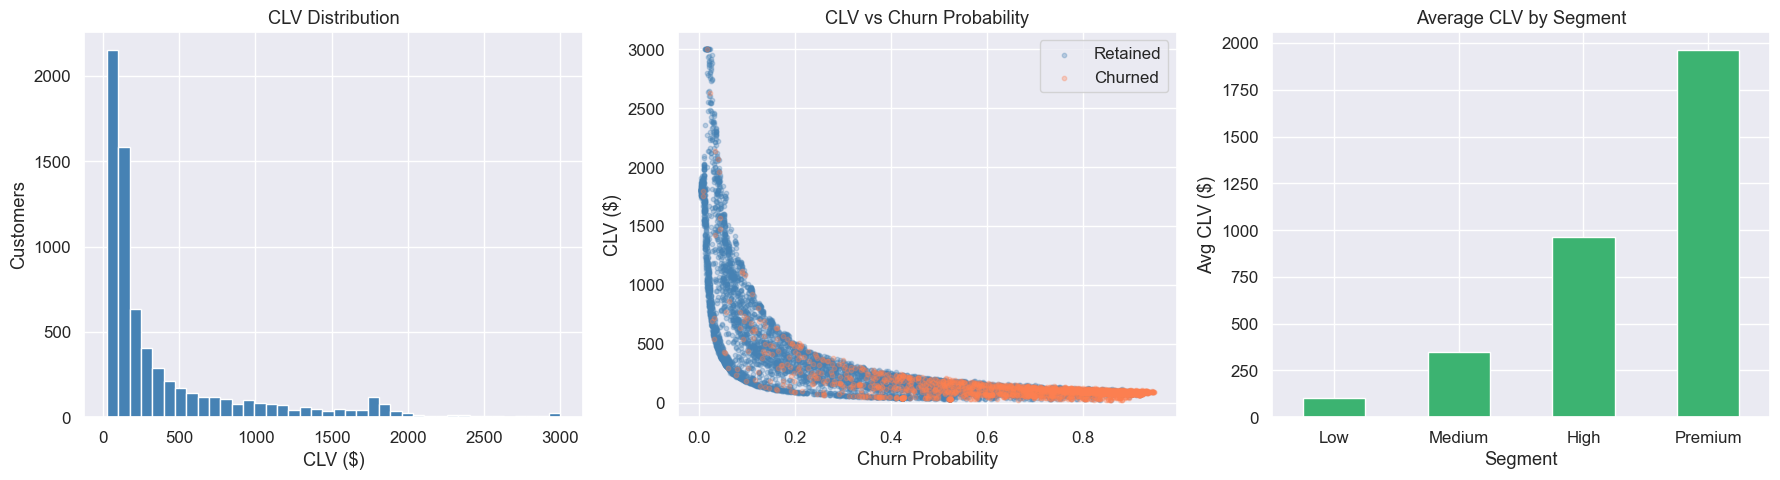

In [29]:
# ── CLV Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CLV distribution
axes[0].hist(clv_df['CLV'].clip(upper=3000), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].set_ylabel('Customers')

# 2. CLV vs Churn Probability
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    mask = clv_df['Churn_Label'] == label
    axes[1].scatter(clv_df.loc[mask, 'churn_probability'],
                    clv_df.loc[mask, 'CLV'].clip(upper=3000),
                    alpha=0.3, color=color, s=10,
                    label='Churned' if label else 'Retained')
axes[1].set_title('CLV vs Churn Probability')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('CLV ($)')
axes[1].legend()

# 3. Avg CLV by Segment
seg_summary['Avg_CLV'].plot(kind='bar', ax=axes[2],
                             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average CLV by Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Avg CLV ($)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [31]:
# ── High-Value At-Risk Customers ──────────────────────────────────────────────

print('=== Churn Probability Distribution ===')
print(clv_df['churn_probability'].describe().round(3))

print('\n=== CLV Distribution ===')
print(clv_df['CLV'].describe().round(2))

print('\n=== CLV Segment Counts ===')
print(clv_df['CLV_Segment'].value_counts())

print('\n=== Customers above churn thresholds ===')
for t in [0.5, 0.4, 0.3, 0.2]:
    n = (clv_df['churn_probability'] >= t).sum()
    print(f'  churn_prob >= {t}: {n:,} customers ({n/len(clv_df):.1%})')

=== Churn Probability Distribution ===
count    7032.000
mean        0.405
std         0.302
min         0.004
25%         0.106
50%         0.385
75%         0.683
max         0.949
Name: churn_probability, dtype: float64

=== CLV Distribution ===
count    7032.00
mean      409.32
std       545.82
min        25.00
25%        91.03
50%       158.12
75%       472.48
max      4513.40
Name: CLV, dtype: float64

=== CLV Segment Counts ===
CLV_Segment
Low        4010
Medium     1547
High        967
Premium     508
Name: count, dtype: int64

=== Customers above churn thresholds ===
  churn_prob >= 0.5: 2,794 customers (39.7%)
  churn_prob >= 0.4: 3,426 customers (48.7%)
  churn_prob >= 0.3: 3,972 customers (56.5%)
  churn_prob >= 0.2: 4,504 customers (64.1%)


In [36]:
# ── Fix: Segment by MonthlyCharges (independent value signal) ────────────────

mq25 = clv_df['MonthlyCharges'].quantile(0.25)
mq50 = clv_df['MonthlyCharges'].quantile(0.50)
mq75 = clv_df['MonthlyCharges'].quantile(0.75)

clv_df['Value_Segment'] = pd.cut(
    clv_df['MonthlyCharges'],
    bins=[0, mq25, mq50, mq75, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium'],
    include_lowest=True
)

print(f'Monthly Charges bins:')
print(f'  Low:     $0 – ${mq25:.0f}')
print(f'  Medium:  ${mq25:.0f} – ${mq50:.0f}')
print(f'  High:    ${mq50:.0f} – ${mq75:.0f}')
print(f'  Premium: ${mq75:.0f}+')

# At-risk: high monthly spend + high churn probability
CHURN_THRESHOLD = clv_df['churn_probability'].quantile(0.70)
high_risk_mask  = clv_df['churn_probability'] >= CHURN_THRESHOLD
high_value_mask = clv_df['Value_Segment'].isin(['High', 'Premium'])

clv_df['at_risk'] = (high_risk_mask & high_value_mask).astype(int)
at_risk = clv_df[clv_df['at_risk'] == 1]

print(f'\nChurn threshold (70th pct):  {CHURN_THRESHOLD:.3f}')
print(f'High risk customers:         {high_risk_mask.sum():,}')
print(f'High/Premium value customers:{high_value_mask.sum():,}')
print(f'Both conditions met:         {(high_risk_mask & high_value_mask).sum():,}')

print(f'\n=== At-Risk Summary ===')
print(f'High-Value At-Risk Customers : {len(at_risk):,}')
print(f'Total Monthly Revenue at Risk: ${at_risk["MonthlyCharges"].sum():,.0f}')
print(f'Average Monthly Charges      : ${at_risk["MonthlyCharges"].mean():,.2f}')
print(f'Average Churn Probability    : {at_risk["churn_probability"].mean():.1%}')
print(f'Average Tenure (months)      : {at_risk["tenure"].mean():.1f}')

print('\n=== Risk × Value Segment Breakdown ===')
clv_df['risk_label'] = np.where(high_risk_mask, 'High Risk', 'Low Risk')
print(pd.crosstab(clv_df['Value_Segment'], clv_df['risk_label'],
                  values=clv_df['MonthlyCharges'], aggfunc='count', margins=True))

Monthly Charges bins:
  Low:     $0 – $36
  Medium:  $36 – $70
  High:    $70 – $90
  Premium: $90+

Churn threshold (70th pct):  0.619
High risk customers:         2,110
High/Premium value customers:3,513
Both conditions met:         1,547

=== At-Risk Summary ===
High-Value At-Risk Customers : 1,547
Total Monthly Revenue at Risk: $136,029
Average Monthly Charges      : $87.93
Average Churn Probability    : 80.0%
Average Tenure (months)      : 16.3

=== Risk × Value Segment Breakdown ===
risk_label     High Risk  Low Risk   All
Value_Segment                           
Low                  106      1652  1758
Medium               457      1304  1761
High                 875       880  1755
Premium              672      1086  1758
All                 2110      4922  7032


In [39]:

print()
print(clv_df['Value_Segment'].dtype)
print(clv_df['Value_Segment'].unique())
print()
print(clv_df[['MonthlyCharges', 'churn_probability', 'Value_Segment', 'risk_label']].head(20))



category
['Low', 'Medium', 'High', 'Premium']
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Premium']

    MonthlyCharges  churn_probability Value_Segment risk_label
0            29.85           0.818250           Low  High Risk
1            56.95           0.101993        Medium   Low Risk
2            53.85           0.523872        Medium   Low Risk
3            42.30           0.089678        Medium   Low Risk
4            70.70           0.899132          High  High Risk
5            99.65           0.919303       Premium  High Risk
6            89.10           0.660103          High  High Risk
7            29.75           0.480540           Low   Low Risk
8           104.80           0.797987       Premium  High Risk
9            56.15           0.045486        Medium   Low Risk
10           49.95           0.323325        Medium   Low Risk
11           18.95           0.035176           Low   Low Risk
12          100.35           0.402841       Premium   Low Risk
13    

In [40]:
# Force string conversion before filtering
clv_df['Value_Segment_str'] = clv_df['Value_Segment'].astype(str)

high_risk_mask  = clv_df['churn_probability'] >= CHURN_THRESHOLD
high_value_mask = clv_df['Value_Segment_str'].isin(['High', 'Premium'])

print(f'High risk:   {high_risk_mask.sum()}')
print(f'High value:  {high_value_mask.sum()}')
print(f'Overlap:     {(high_risk_mask & high_value_mask).sum()}')

High risk:   2110
High value:  3513
Overlap:     1547


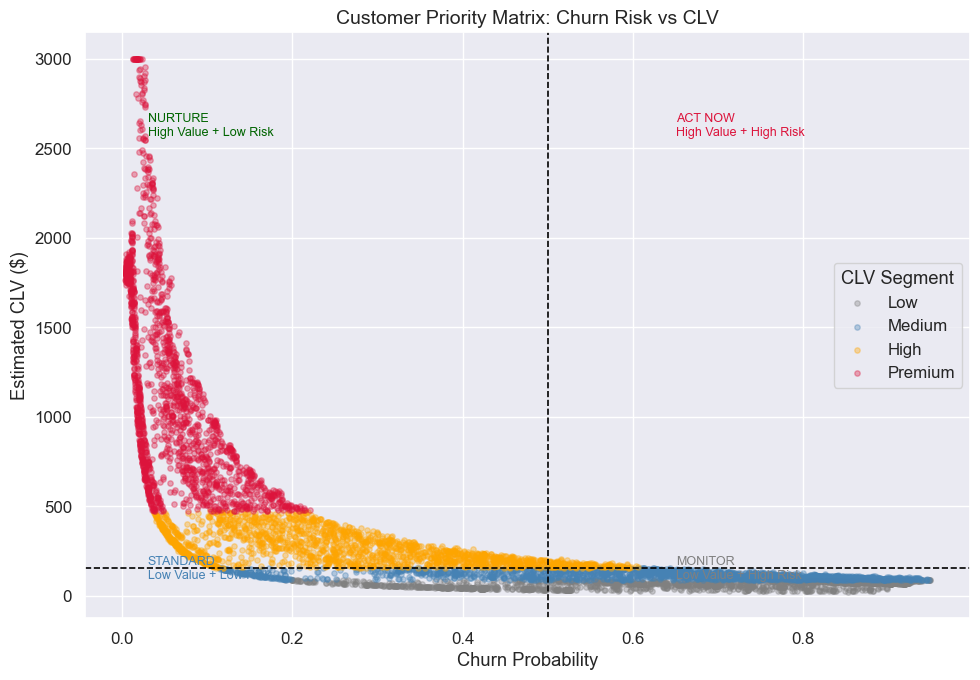

In [42]:
# ── Priority Matrix ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Low': 'grey', 'Medium': 'steelblue', 'High': 'orange', 'Premium': 'crimson'}
for seg, grp in clv_df.groupby('CLV_Segment', observed=True):
    ax.scatter(grp['churn_probability'],
               grp['CLV'].clip(upper=3000),
               label=seg, alpha=0.35,
               color=colors[seg], s=15)

clv_median = clv_df['CLV'].median()
ax.axvline(x=0.5,       color='black', linestyle='--', linewidth=1.2)
ax.axhline(y=clv_median, color='black', linestyle='--', linewidth=1.2)

ax.text(0.65, 2700, 'ACT NOW\nHigh Value + High Risk',  fontsize=9, color='crimson',    va='top')
ax.text(0.65, 80,   'MONITOR\nLow Value + High Risk',   fontsize=9, color='grey',       va='bottom')
ax.text(0.03, 2700, 'NURTURE\nHigh Value + Low Risk',   fontsize=9, color='darkgreen',  va='top')
ax.text(0.03, 80,   'STANDARD\nLow Value + Low Risk',   fontsize=9, color='steelblue',  va='bottom')

ax.set_title('Customer Priority Matrix: Churn Risk vs CLV', fontsize=14)
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Estimated CLV ($)')
ax.legend(title='CLV Segment', loc='center right')
plt.tight_layout()
plt.show()

## Business Recommendations 

### What the Model Tells Us

The top drivers of churn, consistently across models, are:
1. **Contract type** — Month-to-month customers churn at ~3× the rate of two-year subscribers.
2. **Tenure** — The first 12 months are the highest-risk window; customers who survive year 1 are far less likely to leave.
3. **Internet service type** — Fiber optic users churn significantly more than DSL or no-internet users, likely due to pricing or perceived value.
4. **Lack of add-on services** — Customers with few add-ons have lower stickiness.
5. **Monthly charges** — Higher charges, particularly without a long-term contract, increase churn risk.

---

### Priority Action Framework

| Quadrant | Customer Profile | Recommended Action | Expected ROI |
|---|---|---|---|
| 🚨 **Act Now** | High/Premium CLV + Churn Prob ≥ 50% | Proactive outreach: loyalty discount, contract upgrade offer, dedicated support call | High — protecting large revenue |
| 💎 **Nurture** | High/Premium CLV + Churn Prob < 50% | Early renewal incentives, upsell premium bundles, VIP reward programme | Medium — prevent future risk |
| 📊 **Monitor** | Low CLV + Churn Prob ≥ 50% | Low-cost automated retention (email/SMS campaigns) — do not over-invest | Low — limited revenue impact |
| 📌 **Grow** | Low CLV + Churn Prob < 50% | Cross-sell add-on services to increase monthly spend and stickiness | Medium — CLV growth opportunity |

---

### Specific Tactical Levers

**Contract conversion (highest impact)**  
Month-to-month customers flagged at risk should receive a targeted offer to switch to a 1- or 2-year contract at a modest discount. Even a 10% price concession is well worth retaining a Premium CLV customer.

**Onboarding programme for new customers**  
Since months 0–12 are the critical churn window, a structured onboarding sequence (welcome call, check-in at month 3, bundle offer at month 6) can materially reduce early churn.

**Fiber optic investigation**  
The disproportionately high churn among Fiber optic users warrants a root-cause investigation — is it pricing, service quality, or competitive alternatives? A targeted satisfaction survey or pricing review for this segment is recommended.

**Service bundling incentives**  
Customers with fewer than 3 add-on services and a high churn probability are strong candidates for bundled package promotions (e.g., combining streaming + security + tech support at a discount).

**Model operationalisation**  
- Score all customers monthly using the deployed model.
- Push the top 200–300 at-risk High/Premium customers directly into the CRM as a prioritised call list for the retention team.
- Track retained revenue per intervention to calculate actual retention ROI and refine threshold and targeting over time.